# Lab 5 - Solutions

## This notebook should be used in conjunction with the Canvas Quiz: Computational Physics Lab 5. Use the notebook to run scripts and make notes. Submit your final answers on Canvas.

# Part I: Stability of the FTCS and Lax methods for 1-D advection

We analyse the stability of the Forward Time Centred Space (FTCS) scheme, and the Lax method applied to 1-D advection.

advection.ipynb solves the advection equation, $$\frac{\partial a}{\partial t}=-c\frac{\partial a}{\partial x}\quad (c>0)\,,$$ for a Gaussian-pulse initial profile, using either the FTCS or Lax method.

### Forward Time Centred Space (FTCS)

In the lecture, von Neumann analysis was used to obtain the amplification factor for the FTCS method: $$\xi = 1 - ig\sin (kh).$$

It follows that the maximum value of the amplification factor for the FTCS scheme, for a given value of $g = c\tau/h,$ is $$|\xi |_{\rm max} = \sqrt{1 + g^2}.$$


### Lax method

In the lecture, von Neumann analysis was used to obtain the amplification factor $\xi$ for the Lax method: \ $$xi=\cos (kh) -ig\sin (kh).$$

It follows that the maximum value of the amplification factor, for a given value of $g=c\tau/h,$ is $$|\xi |_{\rm max}=1 \quad \text{if} \quad g\leq 1,$$ and $$|\xi |_{\rm max}=g \quad \text{if} \quad g> 1.$$

## <span style="color:red">Q1</span>

<p>For the FTCS method, show that the magnitude \[|\xi| = \sqrt{1 + g^2\sin^2(kh)}\,.\]</p>
<p>From this expression, which of the following (see choices on Canvas) explains why \(|\xi |_{\rm max} = \sqrt{1+g^2}\) for FTCS.</p>
<p>&nbsp;</p>

## <span style="color:red">Answer</span>

<p>We have</p>
<p style="text-align:center">\(\xi = 1-ig\sin(kh) ,\)</p>
<p>so</p>
<p style="text-align:center">\(|\xi| = \sqrt{1 + g^2\sin^2(kh)} \leq \sqrt{1 + g^2} ,\)</p>
<p>since \(\sin^2(kh) \leq 1\).</p>


</span>

## <span style="color:red">Q2</span>

<p>In this question we aim to understand the instability of the FTCS method by investigating the <strong>spectral radius</strong>, \(\rho\), and <strong>amplification factor</strong>, \(\xi\), at different values of \(\tau\).</p>
<p>Modify the FTCS code so that it loops over 25 values of \(\tau\) in the range \(10^{-3}\) to \(10^{-1}\) that are equally spaced logarithmically. You can generate a vector of suitable values using the <strong>logspace</strong> function as follows:</p>
<pre> # Time step values - equally spaced in log
numTau = 25
tauVals = np.logspace(-3,-1,numTau)
</pre>
<p>Use \(c=1\) and \(h=0.01\). In your code, calculate the values of \(g = c\tau/h\) that these choices of \(\tau\) imply. For each value of \(g\), compute the spectral radius, \(\rho\), of the update matrix for the FTCS scheme, i.e., the absolute value of the dominant eigenvalue of the matrix, \(|\lambda_\mathrm{dom}|\).</p>
<p><em>Note:</em> We are analyzing the properties of the update matrix at different values of \(\tau\) so it's not necessary to compute/plot the evolution of the pulse.</p>
<p>Have your code plot \(\rho-1\) as a function of \(g\), with logarithmic scaling on the horizontal axis (using <strong>semilogx</strong> rather than <strong>plot</strong>).  /></p>
<p>Calculate and display \(|\xi |_{\rm max}-1\) as a function of \(g\) on the same plot.</p>
<p>To clearly visualize any the overlap, your plot should use markers for \(\rho -1\) and a line for \(\xi\).</p>


## <span style="color:red">Answer</span>

In [8]:
# from the lecture:

def construct_update_matrix(L, what_method, g):
    # Constructs an update matrix
    # inputs:
    # L is the number of spatial steps
    # what_method sets the method of choice: ftcs or lax
    # g = c*tau/h is a constant
    #-------------------------------------------------------------------------------

    # Diagonal matrix to implement the centred spatial first-derivative
    # Common across both methods
    D = np.zeros((L, L))
        
    # Fill diagonals
    for i in range(L-1):
        D[i, i+1] = 1     # Super-diagonal
        D[i+1, i] = -1    # Sub-diagonal 
        
    # Additional elements for periodic boundary conditions
    D[0, L-1] = -1        
    D[L-1, 0] = 1     
  
    if what_method == 'ftcs':
               
        # FTCS Update matrix for advection
        M = np.eye(L) - 0.5*g*D
        
    elif what_method == 'lax':
        
        # Lax averaging matrix
        A = 0.5*np.abs(D)
        
        # Lax Update matrix for advection
        M = A - 0.5*g*D
        
    else:
        
        raise ValueError(f"Unknown method: '{what_method}'")
    
    return M

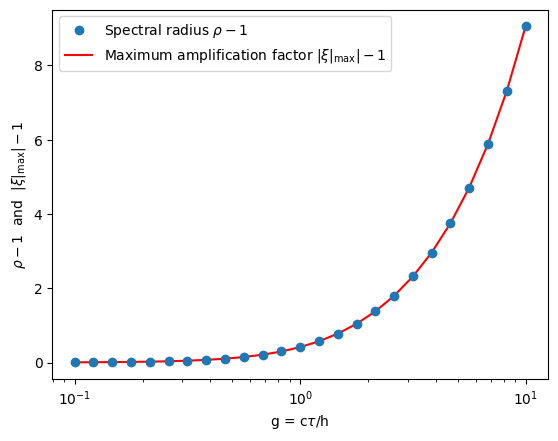

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# We first need to set our logarithmic range of tau values: 

# Time step values - equally spaced in log
numTau = 25
tauVals = np.logspace(-3,-1,numTau)

# Then we can compute the corresponding g values:

# Propagation speed 
c = 1

# Spatial step
h = 0.01

# g values
gVals = c*tauVals/h

#------------- And abs(xi)_max values for ftcs:

maxXi = np.sqrt(1+gVals**2)
#---------------

# To compute the rho values, we can just loop over the g values:

rho = np.zeros(numTau)

x = np.arange(0, 1 + h, h)
L = len(x)

for i in range(numTau):
    
    g = gVals[i]
    
    # Update matrix
    M = construct_update_matrix(L, 'ftcs', g)
    
    # Calculate the spectral radius of M
    rho[i] = max(abs(np.linalg.eigvals(M)))
    
# Then, we can plot the results:

plt.xlabel(r'g = c$\tau$/h')
plt.ylabel(r'$\rho-1$  and  $|\xi|_{\mathrm{max}}|-1$')

plt.semilogx(gVals, rho-1, 'o', label=r'Spectral radius $\rho -1$', zorder=1)
plt.semilogx(gVals, maxXi-1, 'r-', label=r'Maximum amplification factor $|\xi|_{\mathrm{max}}|-1$', zorder=0)

plt.legend();

## <span style="color:red">Q3</span>

<p>From your results, think about the stability of the FTCS scheme and the relationship between \(|\xi|_\mathrm{max}\) and \(\rho\).

Select all answers that apply (see Canvas)</p>


## <span style="color:red">Answer</span>

<p>For FTCS, your plot from Q2 shows that the spectral radius, ρ, is larger than unity for all values of g, and approaches unity asymptotically as g → 0. Hence the scheme is always unstable, as verified by von Neumann analysis. The maximum amplification factor, |ξ|<sub>max</sub>, matches the spectral radius.</p>

## <span style="color:red">Q4</span>

<p>Derive an expression for \(|\xi|\) for the Lax Method in terms of \(g\) and \(\sin^2(kh)\).</p>
<p>From this expression, and by considering the minimum and maximum values of \(\sin^2(kh)\), show that \(|\xi |_{\rm max}\) takes a different form for the two cases: \(g\leq 1\), and \(g&gt;1\) as follows:</p>
<p>\[|\xi |_{\rm max}=1\quad\text{if}\quad g\leq 1,\] and \[|\xi |_{\rm max}=g\quad\text{for}\quad&nbsp; g&gt;1\,.\]</p>



## <span style="color:red">Answer</span>

We have
$$\xi = \cos(kh) - ig\sin(kh),$$

so
$$|\xi| = \sqrt{1 + (g^2 - 1)\sin^2(kh)} .$$

The maximum, $|\xi|_{max}$, thus depends on the sign of the quantity $(g^2 - 1)$. For g ≤ 1, this term is negative, so the second term decreases $|\xi|_{max}$, and when $g > 1$, this term is positive such that the second term increases $|\xi|_{max}$.
    
In the first case, $g ≤ 1$, $|\xi|$ is thus maximized at the minimum value of $sin^2(kh)$ (i.e., 0), yielding $|\xi|_{max}=1.$

In the second case, $g > 1$, $|\xi|$ is maximized at the maximum value of $sin^2(kh)$ (i.e., 1), yielding $|\xi|_{max}=g.$

## <span style="color:red">Q5</span>

<p>Repeat the procedure in Question 2 for the Lax method, and produce the corresponding diagram of \(\rho-1\) versus \(g,\) and of \(|\xi |_{\rm max}-1\) versus \(g\) (on a single plot).</p>
<p>Again, make sure \(\rho -1\) is plotted with markers and \(\xi\) is plotted as a line so that any overlap is clear.</p>
<p>&nbsp;</p>

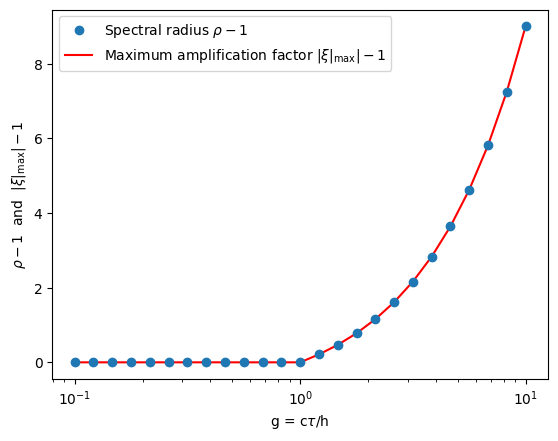

In [10]:
# same as i Q2, but use 'lax' for what_method

import numpy as np
import matplotlib.pyplot as plt

# We first need to set our logarithmic range of tau values: 

# Time step values - equally spaced in log
numTau = 25
tauVals = np.logspace(-3,-1,numTau)

# Then we can compute the corresponding g values:

# Propagation speed 
c = 1

# Spatial step
h = 0.01

# g values
gVals = c*tauVals/h


#------------ And abs(xi)_max values for lax:

maxXi = np.maximum(1.0, gVals)

#-------------

# To compute the rho values, we can just loop over the g values:

rho = np.zeros(numTau)

x = np.arange(0, 1 + h, h)
L = len(x)

for i in range(numTau):
    
    g = gVals[i]
    
    # Update matrix
    M = construct_update_matrix(L, 'lax', g)
    
    # Calculate the spectral radius of M
    rho[i] = max(abs(np.linalg.eigvals(M)))
    
# Then, we can plot the results:

plt.xlabel(r'g = c$\tau$/h')
plt.ylabel(r'$\rho-1$  and  $|\xi|_{\mathrm{max}}|-1$')

plt.semilogx(gVals, rho-1, 'o', label=r'Spectral radius $\rho -1$', zorder=1)
plt.semilogx(gVals, maxXi-1, 'r-', label=r'Maximum amplification factor $|\xi|_{\mathrm{max}}|-1$', zorder=0)

plt.legend();

## <span style="color:red">Q6</span>

<p>From your results, think about the stability of the Lax scheme and the relationship between \(|\xi|_\mathrm{max}\) and \(\rho\).

Select all answers (on Canvas) that apply to the Lax method</p>


## <span style="color:red">Answer</span>

For the Lax method, the spectral radius, $\rho > 1$ when $g > 1$, and $\rho = 1$ for $g \leq 1$.
The maximum amplification factor agrees with the spectral radius.
The method is stable subject to the Courant-Friedrichs-Lewy (CFL) condition, $g \leq 1$.


# Part II: Time-Reversed Diffusion

In the lecture 4, we analysed the stability of the Forward Time Centred Space (FTCS) discretisation of the 1-D diffusion equation: 

$$\frac{\partial T}{\partial t} = \kappa \frac{\partial^2 T}{\partial x^2} \quad (\kappa > 0~~ \text{is constant}).$$

The result was the stability condition  $\kappa\tau/h^2 \leq\frac{1}{2}.$

The 1-D time-reversed diffusion equation is: $$\frac{\partial T}{\partial t} = -\kappa \frac{\partial^2 T}{\partial x^2}\quad (\kappa > 0~~\text{is constant}).$$


## <span style="color:red">Q7</span>

<p>Which of the following (see Canvas) corresponds to the FTCS scheme for the time-reversed diffusion problem (where \(f=\kappa\tau/h^2\)).</p>

## <span style="color:red">Answer</span>

This differs only by the replacement of $f$ by $-f$ in the results for the 1-D diffusion equation.
The FTCS scheme for time-reversed diffusion is
$$
T_j^{n+1} = T_j^n - f\left(T_{j-1}^n - 2T_{j}^n + T_{j+1}^n\right) \quad \mbox{with $f = \kappa\tau/h^2$}\,.
$$



## <span style="color:red">Q8</span>

Apply von Neumann stability analysis to determine the stability of the FTCS scheme for time-reversed diffusion.



Which of the following is a correct statement about the stability?

## <span style="color:red">Answer</span>

Applying von Neumann stability analysis, the amplification factor yields

$$
\xi = 1 + 4f\sin^2 \left(\tfrac{1}{2}kh\right)\,.
$$

Hence $|\xi|^2 > 1$ for some $k$ for all $\tau >0$, and the method is **unconditionally unstable.**

## <span style="color:red">Q9</span>

<p>Consider analytically how a peak in a temperature profile&nbsp;(a region where \(T(x,t)\) has a maximum, and \(\partial^2 T/\partial x^2&lt;0\)) evolves in time, according to the 1-D diffusion equation, and how it evolves in time according to the 1-D time-reversed diffusion equation.</p>
<p>Based on this, consider the situation that a small amount of noise is added to a constant temperature profile, and the system then evolves in time according to the time-reversed diffusion equation.

Select all valid answers about this situation from the optionson Canvas</p>


## <span style="color:red">Answer</span>

At a peak we have $\partial^2T/\partial x^2 < 0$ (a peak is locally concave down).
The 1-D diffusion equation PDE then implies $\partial T/\partial t<0$, and the peak smooths out with time.
However, for the time-reversed diffusion PDE the concave down condition implies $\partial T/\partial t > 0$, i.e., a peak grows with time.
With time-reversed diffusion, peaks continuously grow and $T\rightarrow \infty$ at a peak.

If noise is added to a constant initial temperature profile, then for time-reversed diffusion, small local maxima due to the noise grow arbitrarily (including
small dips leading to $T\rightarrow - \infty$).
This accounts for the 'instability' of time-reversed diffusion identified by von Neumann analysis.
Time-reversed diffusion gives physically unrealistic behavior (arbitrary growth of noise is not observed in real physical systems, and temperature doesn't become
negative).
